# Composer Classification from Cello Audio Features
This notebook demonstrates an end-to-end machine learning pipline for classifying short cello audio clips by composer (Bach, Beethoven, Schumann).
Rather than focusing on dataset construction, the goal here is to examine how extracted audio features behave, how they are used by a model, and how well they support classification.

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# learning model

# Style
plt.style.use("default")

## Data Overview
Each row corresponds to a fixed-length audio clip represented by extracted numerical features.

In [40]:
df = pd.read_csv(r"D:\Documents\Portfolio\cello-repertoire-classifier\data\features.csv")
r = df.drop(columns=["filepath"])
print("Shape:", r.shape)
r.groupby("label").head(1)

Shape: (1096, 935)


,filename,label,tempo,zrc_mean,zrc_std,rms_mean,rms_std,spectral_centroid_mean,spectral_centroid_std,spectral_bandwith_mean,...,mfcc_9_mean,mfcc_9_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std
0,bach_suite_cello_2_minuet_1_2_clip_000.wav,bach,151.999081,0.066047,0.053078,0.031151,0.022044,1382.579909,859.050259,1539.223802,...,-5.532957,8.040714,-5.210244,7.544612,-14.867672,7.904020,-6.609782,5.879679,-10.857041,6.993967
368,beethoven_sonata3_1mov_clip_000.wav,beethoven,107.666016,0.023859,0.007746,0.031693,0.018267,624.994273,111.001064,1006.750397,...,-3.172856,7.163393,1.460951,6.083739,0.591082,4.866507,-2.263114,6.873178,0.202085,7.072026
750,schumann_adagio_allegro_clip_000.wav,schumann,123.046875,0.067558,0.034597,0.015797,0.013378,1941.248304,1331.978577,1974.896205,...,-5.453185,8.806647,-8.160254,9.892089,-12.637591,12.745204,-3.035244,5.959212,-10.410228,12.442668


## Class Distribution
We first verify the balance of clips across composers in order to determine reliability.

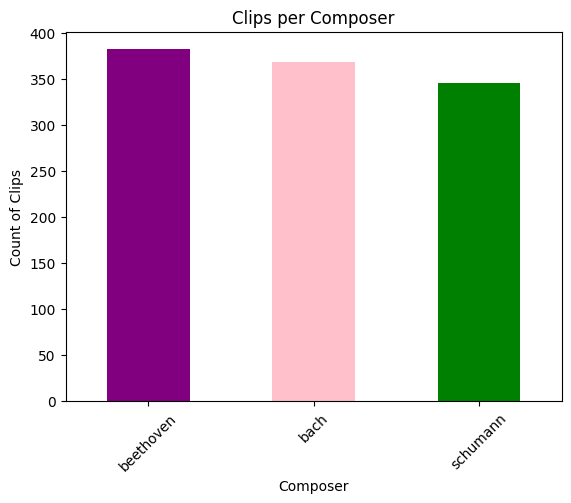

In [18]:
counts = df["label"].value_counts()
bar_colors = ["purple", "pink", "green"]
plt.figure()
counts.plot(kind="bar", color = bar_colors)
plt.title("Clips per Composer")
plt.xlabel("Composer")
plt.ylabel("Count of Clips")
plt.xticks(rotation = 45)
plt.show()

## Feature Representation
The dataset consists of numerical representations that capture energy, spectral, and tonal characteristics.

In [27]:
X = df.drop(columns = ["filepath", "label"])
y = df["label"]
print("Feature matrix shape:", X.shape)

Feature matrix shape: (1096, 934)


## Feature Inspection / Distribution
We examine the distribution of individual features to understand scale and varibiablity before moving forward.

In [46]:
examplefeature = sns.load_dataset["tempo"]
plt.figure()
sns.histplot(data = examplefeature, x = "Example Feature = Tempo (bpm)", hue = "label", multiple = "stack")
plt.show()

TypeError: 'function' object is not subscriptable